In [142]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Overview datasets

We have these parameters

- Cosine similarity threshold
- Approach to select data
- Level of the nace class description

And we want to optimize 

1. Menge
2. Ausgeglichenheit über alle Klassen
3. Qualität
    - **can only be measured by reading :/**


In [143]:
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling"

datasets = [
    {
        "path": "projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4",
        "approach": 2, 
        "level": 1
    }, 
    {
        "path": "projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1",
        "approach": 1, 
        "level": 1
    }, 
    {
        "path": "projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1", 
        "approach": 1, 
        "level": 2
    }, 
    {
        "path": "projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1", 
        "approach": 1, 
        "level": 3
    }, 
    {
        "path": "projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_4__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1", 
        "approach": 1, 
        "level": 4
    }
    ]

In [144]:
%pwd

'/data/resources/weichel-llama3/work'

In [145]:
pd.read_csv("projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1/statistics.csv")

,Unnamed: 0,Code,Nbr. of Chunks,Avg. Length,Avg. Score,Min. Score,Max. Score
0,17,A,1221,436.366093,0.438466,0.400074,0.590924
1,9,B,4754,546.968027,0.468794,0.400061,0.685280
2,3,C,2112,562.233428,0.444879,0.400021,0.639577
3,7,D,5327,542.697391,0.469544,0.400019,0.715047
4,5,E,2600,533.650385,0.482233,0.400005,0.770882
5,0,F,5592,528.193848,0.489546,0.400028,0.792728
6,11,G,5311,550.643570,0.442227,0.400010,0.702519
7,10,H,5760,495.011806,0.461356,0.400074,0.702126
8,13,I,2528,431.217563,0.444733,0.400003,0.684293
9,8,J,1147,585.095902,0.453166,0.400018,0.689055


Index(['NACE_Code', 'Sentences', 'Score'], dtype='object')
{'path': 'projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4', 'approach': 2, 'level': 1}


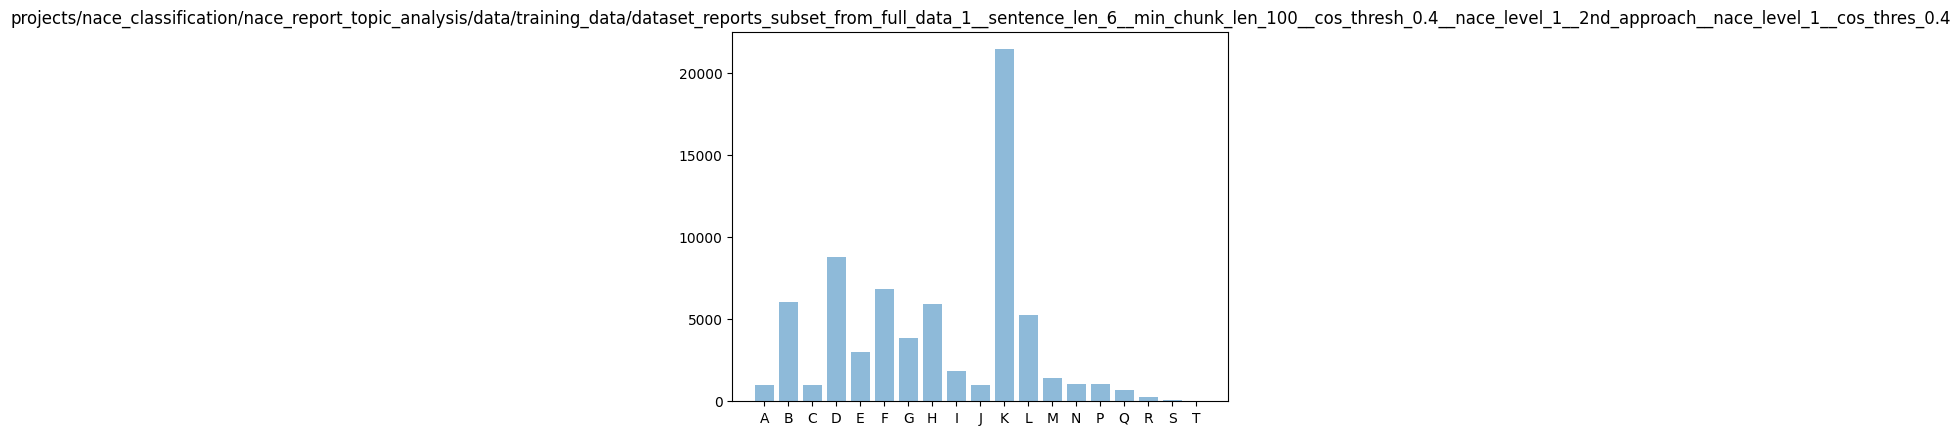

Index(['Unnamed: 0', 'Code', 'Nbr. of Chunks', 'Avg. Length', 'Avg. Score',
       'Min. Score', 'Max. Score'],
      dtype='object')
{'path': 'projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1', 'approach': 1, 'level': 1}


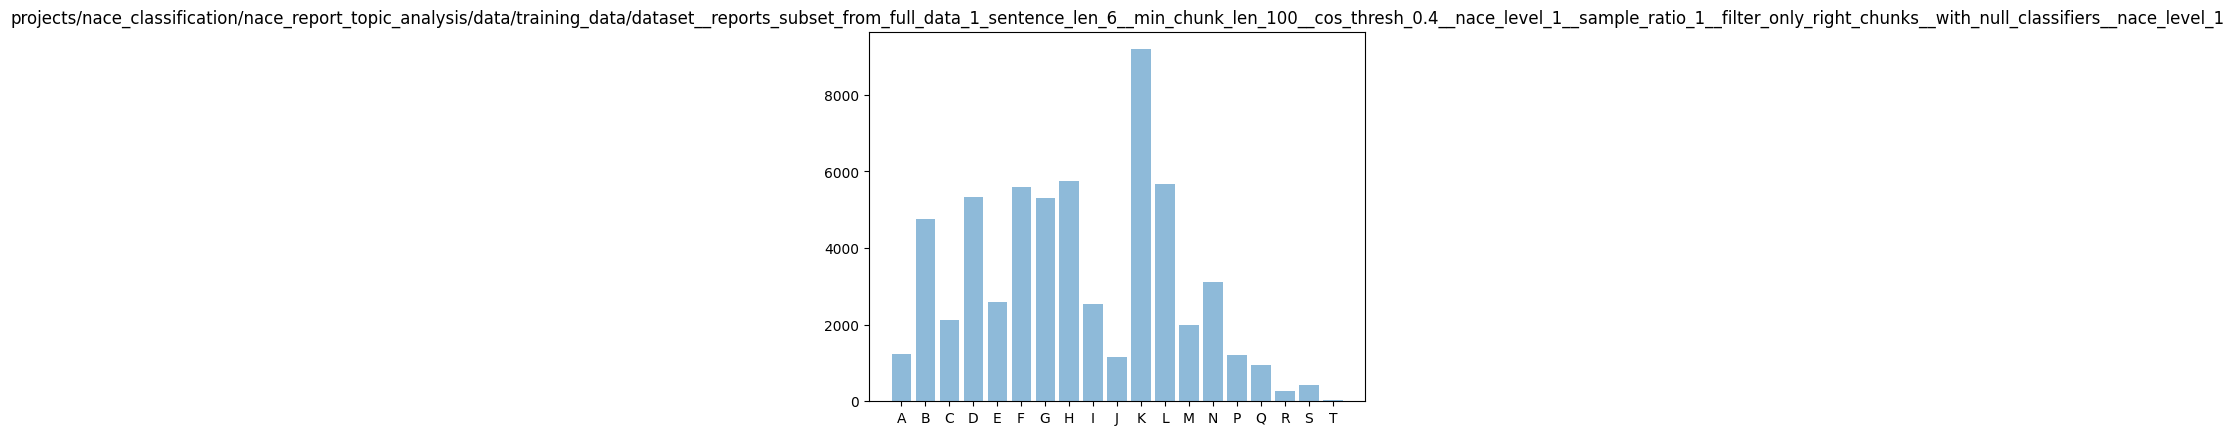

Index(['NACE_Code', 'Sentences', 'Score'], dtype='object')
{'path': 'projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1', 'approach': 1, 'level': 2}


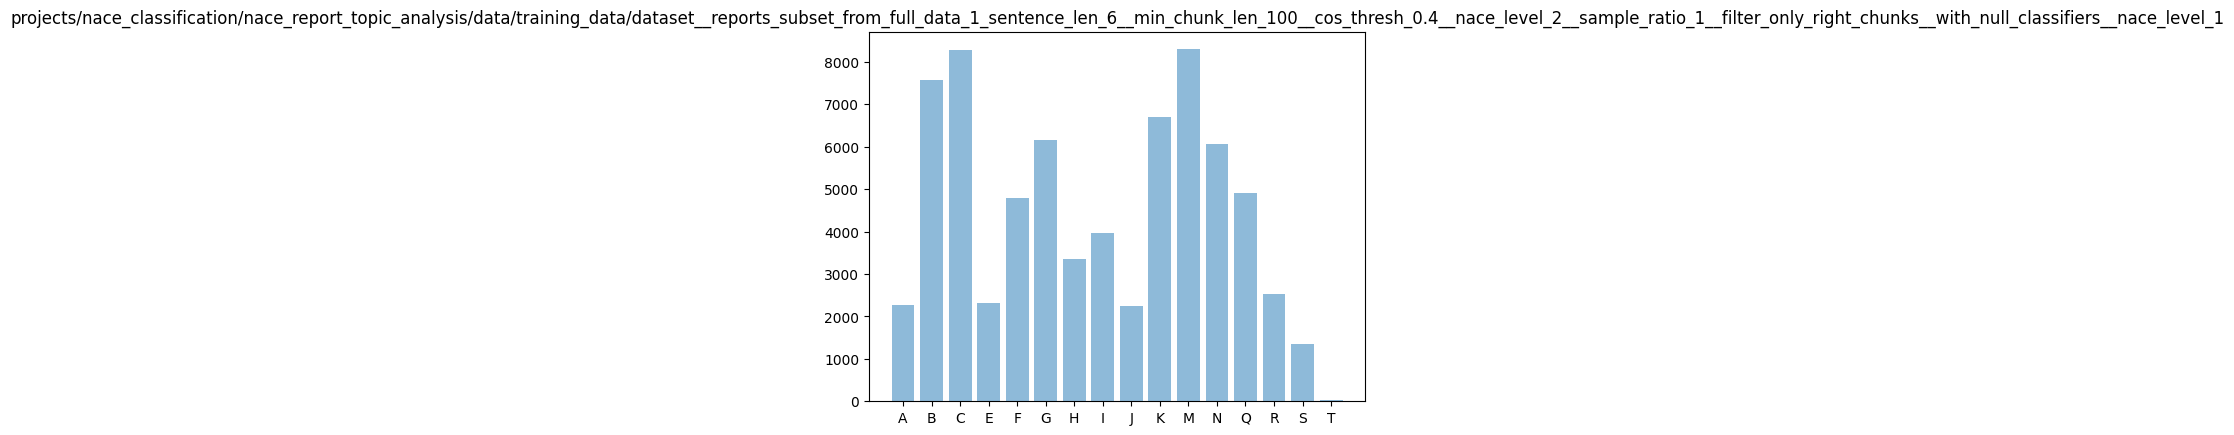

Index(['NACE_Code', 'Sentences', 'Score'], dtype='object')
{'path': 'projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_3__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1', 'approach': 1, 'level': 3}


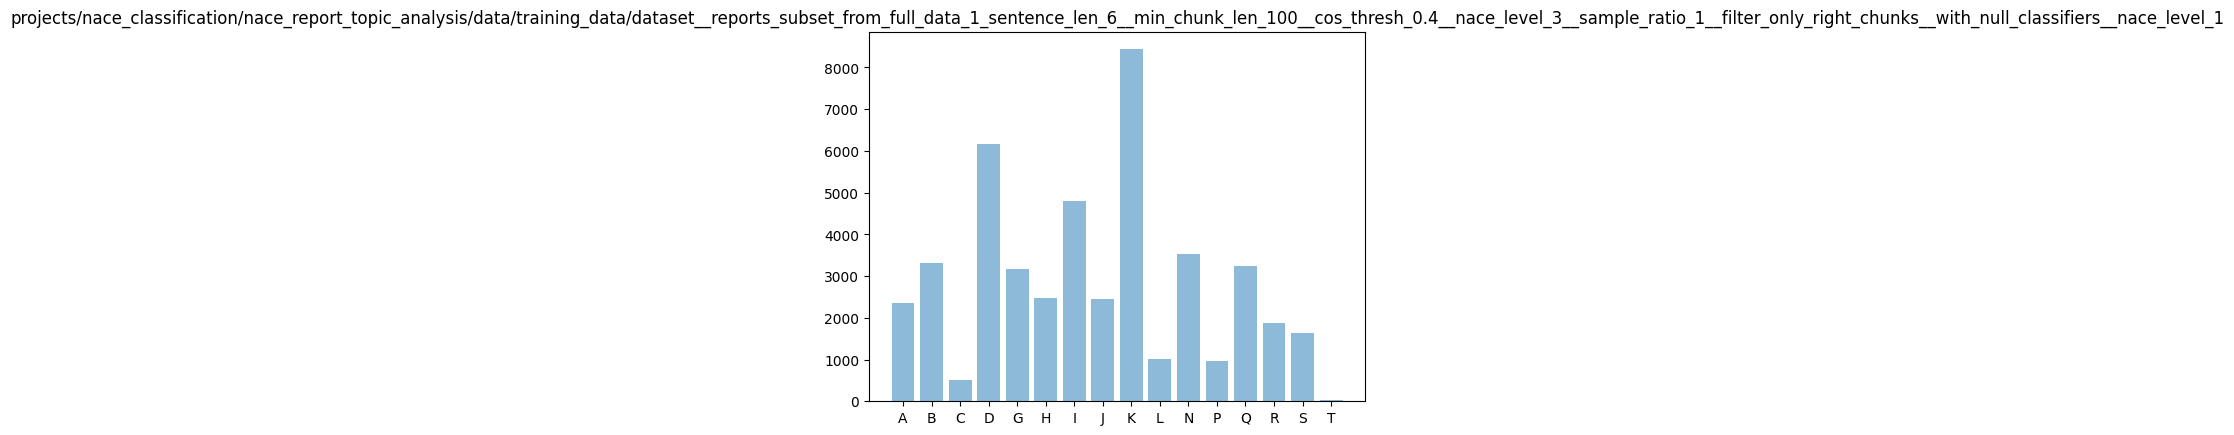

Index(['Unnamed: 0', 'Code', 'Nbr. of Chunks', 'Avg. Length', 'Avg. Score',
       'Min. Score', 'Max. Score'],
      dtype='object')
{'path': 'projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_4__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1', 'approach': 1, 'level': 4}


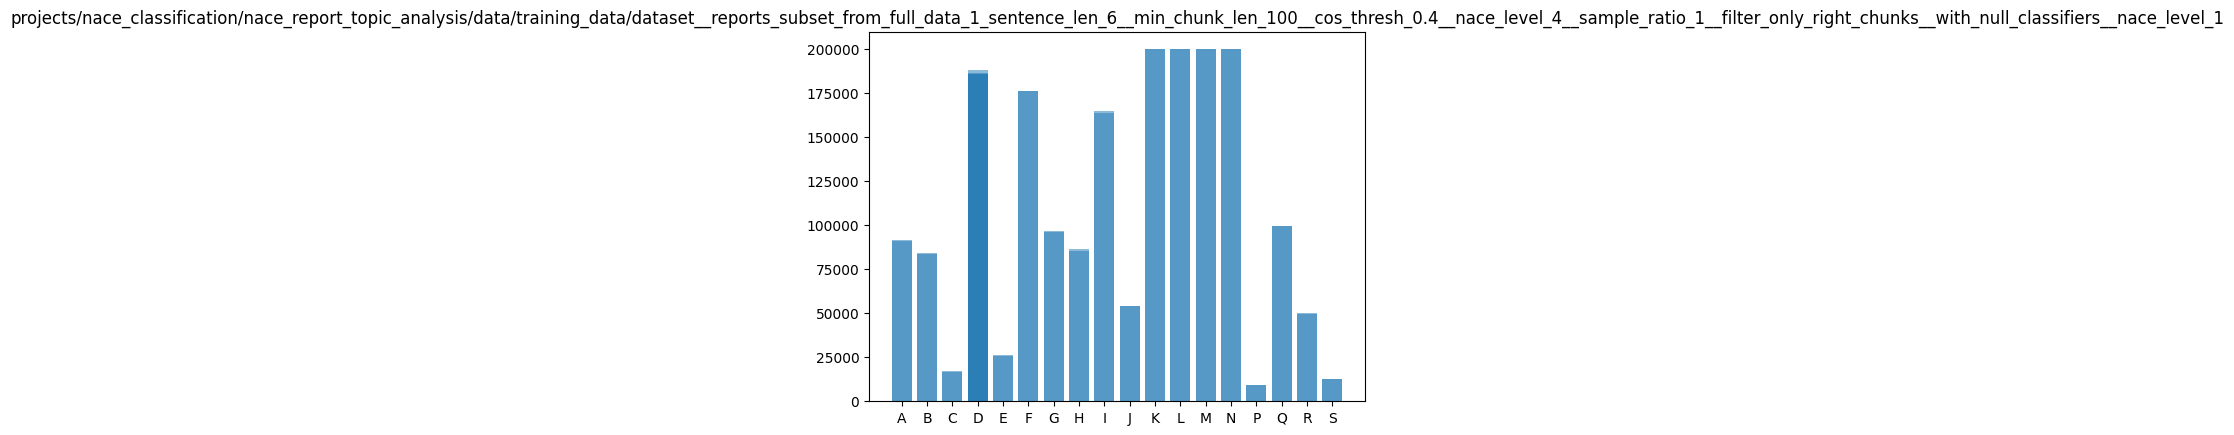

In [149]:
# Compare length

for dataset in datasets: 
    df = pd.read_csv(dataset["path"] + "/statistics.csv")
    print(df.columns)
    print(dataset)
    #print(df.to_markdown())
    if "Nbr. of Chunks" in df.columns:
        plt.bar(df["Code"], df["Nbr. of Chunks"], alpha = 0.5)
    else:
        df = df[df["NACE_Code"] != "NO_CLASS"]
        plt.bar(df["NACE_Code"], df["Sentences"], alpha = 0.5)

    plt.title(dataset["path"])
    plt.show()

In [158]:
for dataset in datasets: 
    print()
    print(dataset)
    df = pd.read_csv(dataset["path"] + "/statistics.csv")
    if "Code" in df.columns: 
        df = df[df["Code"] != "NO_CLASS"]
        print(df["Avg. Score"].mean())
    else: 
        df = df[df["NACE_Code"] != "NO_CLASS"]
        print(df["Score"].mean())

    print(df.columns)


{'path': 'projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4', 'approach': 2, 'level': 1}
0.4532858155057407
Index(['NACE_Code', 'Sentences', 'Score'], dtype='object')

{'path': 'projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks__with_null_classifiers__nace_level_1', 'approach': 1, 'level': 1}
0.45274797060065136
Index(['Unnamed: 0', 'Code', 'Nbr. of Chunks', 'Avg. Length', 'Avg. Score',
       'Min. Score', 'Max. Score'],
      dtype='object')

{'path': 'projects/nace_classification/nace_report_topic_analysis/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_2__sample_ratio_1

In [4]:
stats = pd.read_csv(data_path + "/statistics.csv")

In [5]:
stats.sort_values(by="Code")

,Unnamed: 0,Code,Nbr. of Chunks,Avg. Length,Avg. Score
4,4,A,1221,436.366093,0.438466
7,7,B,4754,546.968027,0.468794
2,2,C,2112,562.233428,0.444879
11,11,D,5327,542.697391,0.469544
1,1,E,2600,533.650385,0.482233
10,10,F,5592,528.193848,0.489546
13,13,G,5311,550.643570,0.442227
18,18,H,5760,495.011806,0.461356
12,12,I,2528,431.217563,0.444733
0,0,J,1147,585.095902,0.453166


Text(0, 0.5, 'Nbr. of paragraphs')

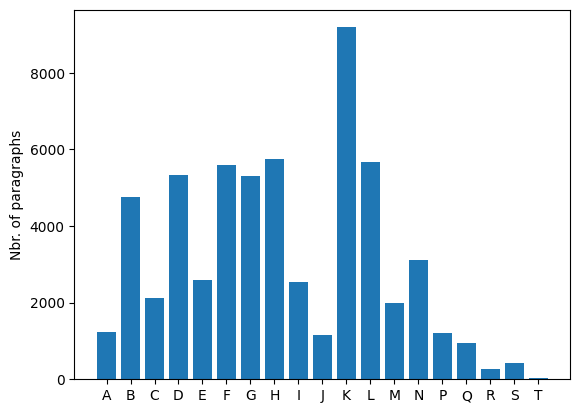

In [6]:
plt.bar(stats.sort_values(by="Code")["Code"], stats.sort_values(by="Code")["Nbr. of Chunks"])
plt.ylabel("Nbr. of paragraphs")

In [7]:
df["Score"].min()

0.4000050025293803

In [8]:
df.groupby("NACE_Code").count()

,Evaluation,Notes,text,Score
NACE_Code,,,,
A,0,0,706,706
B,0,0,2819,2819
C,0,0,1267,1267
D,0,0,3173,3173
E,0,0,1556,1556
F,0,0,3403,3403
G,0,0,3167,3167
H,0,0,3413,3413
I,0,0,1530,1530


In [9]:
df = df[df["Score"] > 0.5]
df.groupby("NACE_Code").count()

,Evaluation,Notes,text,Score
NACE_Code,,,,
A,0,0,45,45
B,0,0,665,665
C,0,0,149,149
D,0,0,757,757
E,0,0,514,514
F,0,0,1303,1303
G,0,0,279,279
H,0,0,654,654
I,0,0,150,150


In [22]:
l = []
for i in np.arange(0.4, 0.9, 0.01):
    df_temp = df[df["Score"] > i]
    l.append(df_temp["Score"].sum())

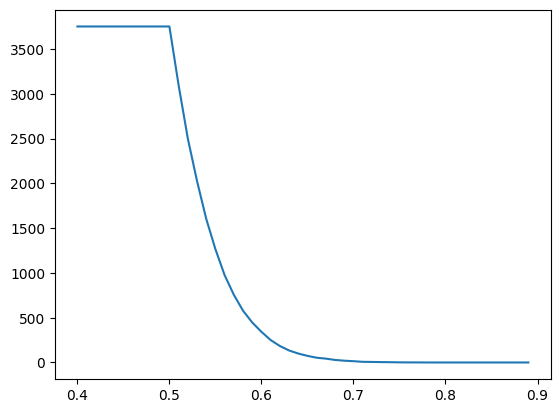

In [24]:
plt.plot(np.arange(0.4, 0.9, 0.01), l)

In [25]:
df[df["Score"] > 0.6]

,Evaluation,Notes,text,Score,NACE_Code
22,NaN,NaN,iv. to carry out the business of building cons...,0.645458,L
69,NaN,NaN,. both parties must support the sale supervisi...,0.658698,H
99,NaN,NaN,description international transportation regio...,0.605850,H
146,NaN,NaN,the group determines the performance progress ...,0.627986,F
192,NaN,NaN,i examined the recognition of revenue from con...,0.602940,F
...,...,...,...,...,...
35396,NaN,NaN,a contract with a customer is classified by th...,0.625169,F
35408,NaN,NaN,looking forward the near future the group will...,0.607995,F
35425,NaN,NaN,survey and design by region . domestic . overs...,0.627945,F
35439,NaN,NaN,infrastructure construction general contract f...,0.616637,F
